# LAB-03: Descriptive Statistical Analysis

**Aim**: Applying statistical techniques to summarize, explore, and interpret datasets in a meaningful way before applying machine learning models.

## Setup & Data Loading
Load the StudentsPerformance.csv dataset and identify numerical and categorical columns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Load the dataset
df = pd.read_csv("../StudentsPerformance.csv")

display(df.head())

# Identify columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



Numerical Columns: ['math score', 'reading score', 'writing score']
Categorical Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## Experiment-1: Measures of Central Tendency & Dispersion
Compute mean, median, mode, minimum, maximum, sum, variance, and standard deviation for selected numerical attributes.

In [2]:
# Central Tendency
print("--- Central Tendency ---")
for col in num_cols:
    print(f"\nFeature: {col}")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    # mode() returns a Series, so we grab the first element
    print(f"  Mode: {df[col].mode()[0]}")

# Dispersion
print("\n--- Measures of Dispersion ---")
for col in num_cols:
    print(f"\nFeature: {col}")
    print(f"  Min: {df[col].min()} | Max: {df[col].max()}")
    print(f"  Sum: {df[col].sum()}")
    print(f"  Variance: {df[col].var():.2f}")
    print(f"  Std Deviation: {df[col].std():.2f}")

--- Central Tendency ---

Feature: math score
  Mean: 66.09
  Median: 66.00
  Mode: 65

Feature: reading score
  Mean: 69.17
  Median: 70.00
  Mode: 72

Feature: writing score
  Mean: 68.05
  Median: 69.00
  Mode: 74

--- Measures of Dispersion ---

Feature: math score
  Min: 0 | Max: 100
  Sum: 66089
  Variance: 229.92
  Std Deviation: 15.16

Feature: reading score
  Min: 17 | Max: 100
  Sum: 69169
  Variance: 213.17
  Std Deviation: 14.60

Feature: writing score
  Min: 10 | Max: 100
  Sum: 68054
  Variance: 230.91
  Std Deviation: 15.20


## Experiment-2: Quartiles
Compute first quartile (Q1), second quartile (median), and third quartile (Q3) and interpret their significance.

In [3]:
print("--- Quartiles ---")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Median = df[col].quantile(0.50)
    Q3 = df[col].quantile(0.75)
    print(f"\nFeature: {col}")
    print(f"  Q1 (25th percentile): {Q1}")
    print(f"  Second Quartile (Median): {Median}")
    print(f"  Q3 (75th percentile): {Q3}")
    print(f"  Interquartile Range (IQR): {Q3 - Q1}")

--- Quartiles ---

Feature: math score
  Q1 (25th percentile): 57.0
  Second Quartile (Median): 66.0
  Q3 (75th percentile): 77.0
  Interquartile Range (IQR): 20.0

Feature: reading score
  Q1 (25th percentile): 59.0
  Second Quartile (Median): 70.0
  Q3 (75th percentile): 79.0
  Interquartile Range (IQR): 20.0

Feature: writing score
  Q1 (25th percentile): 57.75
  Second Quartile (Median): 69.0
  Q3 (75th percentile): 79.0
  Interquartile Range (IQR): 21.25


## Experiment-3: Correlation and Covariance
Compute correlation coefficients and covariance between numerical features.

In [4]:
# Correlation
corr_matrix = df[num_cols].corr()
print("--- Correlation Matrix ---\n")
display(corr_matrix)
print("Interpretation: Correlation measures the strength and direction of the linear relationship between two variables (bounded -1 to 1). E.g., reading and writing scores are highly positively correlated.")

# Covariance
cov_matrix = df[num_cols].cov()
print("\n--- Covariance Matrix ---\n")
display(cov_matrix)
print("Interpretation: Covariance indicates the direction of the linear relationship but is unbounded, making its magnitude harder to interpret compared to correlation.")

--- Correlation Matrix ---



,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


Interpretation: Correlation measures the strength and direction of the linear relationship between two variables (bounded -1 to 1). E.g., reading and writing scores are highly positively correlated.

--- Covariance Matrix ---



,math score,reading score,writing score
math score,229.918998,180.998958,184.939133
reading score,180.998958,213.165605,211.786661
writing score,184.939133,211.786661,230.907992


Interpretation: Covariance indicates the direction of the linear relationship but is unbounded, making its magnitude harder to interpret compared to correlation.


## Experiment-4: Histograms & Boxplots
Plot histograms to analyze data distribution and identify skewness. Use boxplots to visualize quartiles, IQR, and potential outliers.

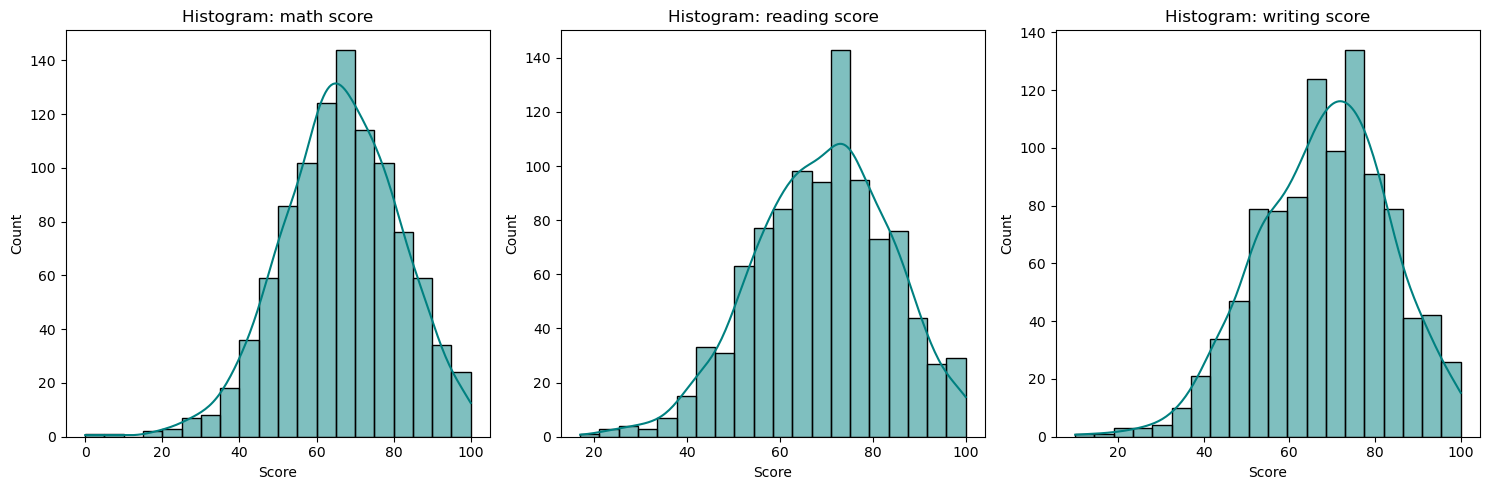

Interpretation: The histograms show slightly left-skewed (negative skew) normal distributions, meaning the bulk of the scores are high, with a few exceptionally low scores trailing to the left.


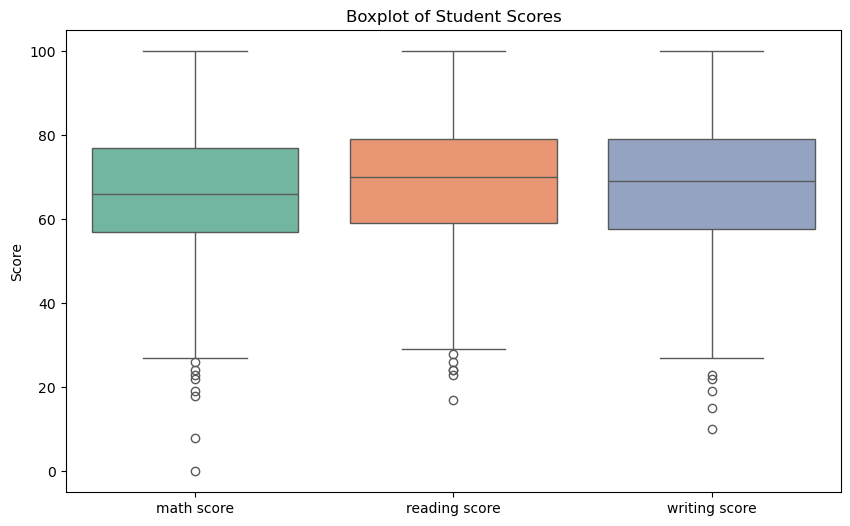

Interpretation: Boxplots reveal several outliers on the lower end (below the lower whisker) for all three subjects.


In [5]:
plt.figure(figsize=(15, 5))

# Histograms
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='teal')
    plt.title(f"Histogram: {col}")
    plt.xlabel("Score")

plt.tight_layout()
plt.savefig('outputs/histograms.png')
plt.show()

print("Interpretation: The histograms show slightly left-skewed (negative skew) normal distributions, meaning the bulk of the scores are high, with a few exceptionally low scores trailing to the left.")

# Boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[num_cols], palette='Set2')
plt.title("Boxplot of Student Scores")
plt.ylabel("Score")
plt.savefig('outputs/boxplots.png')
plt.show()

print("Interpretation: Boxplots reveal several outliers on the lower end (below the lower whisker) for all three subjects.")